<a href="https://colab.research.google.com/github/WatsonWBlair/cs667/blob/main/Projects/Interpretability/notebooks/member_b_tree_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 00 - Data Preparation (Shared Foundation)
## CS667 Project 4: ML Interpretability

**IMPORTANT**: This notebook must be run FIRST by any team member. It creates the train/test split that ALL members must use for consistency.

### Objectives:
1. Download and load the Heart Failure dataset
2. Perform initial data validation
3. Create a reproducible train/test split
4. Save split data for all team members to use

---
## 1. Setup and Imports

In [ ]:
# Install required package for fetching UCI datasets
%pip install ucimlrepo -q

In [ ]:
import os

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

# CRITICAL: All team members MUST use these exact values
RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COLUMN = 'DEATH_EVENT'

# UCI Repository dataset ID for Heart Failure Clinical Records
UCI_DATASET_ID = 519

print(f"Random State: {RANDOM_STATE}")
print(f"Test Size: {TEST_SIZE}")
print(f"Target Column: {TARGET_COLUMN}")
print(f"UCI Dataset ID: {UCI_DATASET_ID}")

Random State: 42
Test Size: 0.2
Target Column: DEATH_EVENT
UCI Dataset ID: 519


---
## 2. Load Data from UCI Repository

We use the `ucimlrepo` library to fetch the Heart Failure Clinical Records dataset directly from the UCI Machine Learning Repository.

**Dataset Info:**
- **Name**: Heart Failure Clinical Records
- **UCI ID**: 519
- **URL**: https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records

### Investigation Prompt:
> Before loading, what do you expect from a dataset with 299 patients and 13 features? What preprocessing challenges might arise with clinical data?

In [ ]:
# Fetch dataset from UCI repository
heart_failure = fetch_ucirepo(id=UCI_DATASET_ID)

# Extract features (X) and target (y)
X = heart_failure.data.features
y = heart_failure.data.targets

# Combine into a single DataFrame for exploration
data = X.copy()
data[TARGET_COLUMN] = y

print(f"Dataset: {heart_failure.metadata.name}")
print(f"Dataset shape: {data.shape}")
print(f"\nFeatures: {list(X.columns)}")
print(f"Target: {list(y.columns)}")

Dataset: Heart Failure Clinical Records
Dataset shape: (299, 13)

Features: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']
Target: ['death_event']


---
## 3. Initial Data Exploration

### Investigation Prompts:
> - What data types are present? Are they appropriate for each feature?
> - Are there any missing values? How would missing clinical data affect predictions?
> - What is the class balance of the target variable? Why does this matter for classification?

In [ ]:
# TODO: Display basic information about the dataset
# Use: data.info(), data.describe(), data.head()

print("=== Dataset Info ===")
data.info()

print("\n=== Statistical Summary ===")
print(data.describe())

print("\n=== First 5 Rows ===")
data.head()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
# TODO: Check for missing values
print("\n=== Missing Values ===")
print(data.isnull().sum())


=== Missing Values ===
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
# TODO: Check class balance of target variable
# Hint: Use value_counts() on the TARGET_COLUMN

print("=== Target Variable Distribution ===")
# YOUR CODE HERE
data['DEATH_EVENT'].value_counts()

# Calculate percentage
percentage_distribution = data['DEATH_EVENT'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'
print(percentage_distribution)

=== Target Variable Distribution ===
DEATH_EVENT
0    67.89%
1    32.11%
Name: proportion, dtype: object


---
## 4. Feature Overview

| Feature | Type | Description |
|---------|------|-------------|
| age | Continuous | Age of patient (years) |
| anaemia | Binary | Decrease of red blood cells or hemoglobin |
| creatinine_phosphokinase | Continuous | Level of CPK enzyme in blood (mcg/L) |
| diabetes | Binary | If patient has diabetes |
| ejection_fraction | Continuous | % of blood leaving heart at each contraction |
| high_blood_pressure | Binary | If patient has hypertension |
| platelets | Continuous | Platelets in blood (kiloplatelets/mL) |
| serum_creatinine | Continuous | Level of serum creatinine (mg/dL) |
| serum_sodium | Continuous | Level of serum sodium (mEq/L) |
| sex | Binary | Woman (0) or Man (1) |
| smoking | Binary | If patient smokes |
| time | Continuous | Follow-up period (days) |
| **DEATH_EVENT** | **Binary** | **Target: If patient deceased during follow-up** |

### Investigation Prompt:
> Which features would you hypothesize are most predictive of mortality? Why?

In [ ]:
print("Correlation with Target Variable (DEATH_EVENT)\n")

# Calculate the correlation of all features with the target
correlation_to_target = data.corr()[TARGET_COLUMN].sort_values(ascending=False)

# Drop the correlation of the target with itself (which is 1.0)
predictive_ranking = correlation_to_target.drop(TARGET_COLUMN)

# Print the results
print("Feature Ranking (Magnitude of Correlation to Mortality):")
print("-" * 60)
# Use abs() to rank by strength, regardless of direction (+/-)
ranked_features = predictive_ranking.abs().sort_values(ascending=False)
print(ranked_features.to_string())
print("-" * 60)

# Print the correlation with its sign (Direction of impact)
print("\nCorrelation Sign (Direction of Impact):")
print(predictive_ranking.loc[ranked_features.index].to_string())

 Correlation with Target Variable (DEATH_EVENT)

Feature Ranking (Magnitude of Correlation to Mortality):
------------------------------------------------------------
time                        0.526964
serum_creatinine            0.294278
ejection_fraction           0.268603
age                         0.253729
serum_sodium                0.195204
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
platelets                   0.049139
smoking                     0.012623
sex                         0.004316
diabetes                    0.001943
------------------------------------------------------------

Correlation Sign (Direction of Impact):
time                       -0.526964
serum_creatinine            0.294278
ejection_fraction          -0.268603
age                         0.253729
serum_sodium               -0.195204
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    

In [ ]:
# Identify feature types for later use
BINARY_FEATURES = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
CONTINUOUS_FEATURES = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                       'platelets', 'serum_creatinine', 'serum_sodium', 'time']
CONTINUOUS_T_FEATURES = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                       'platelets', 'serum_creatinine', 'serum_sodium']

print(f"Binary features ({len(BINARY_FEATURES)}): {BINARY_FEATURES}")
print(f"Continuous features ({len(CONTINUOUS_FEATURES)}): {CONTINUOUS_FEATURES}")
print(f"Target: {TARGET_COLUMN}")

Binary features (5): ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
Continuous features (7): ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']
Target: DEATH_EVENT


OUTLIER DETECTION - IQR METHOD

AGE:
  Outlier count: 0 (0.00%)者に 0.00%) 
  Valid range: [22.50, 98.50] 

CREATININE_PHOSPHOKINASE:
  Outlier count: 29 (9.70%)者に 9.70%) 
  Valid range: [-581.75, 1280.25] 

EJECTION_FRACTION:
  Outlier count: 2 (0.67%)者に 0.67%) 
  Valid range: [7.50, 67.50] 
  Outlier values: [80 70]

PLATELETS:
  Outlier count: 21 (7.02%)者に 7.02%) 
  Valid range: [76000.00, 440000.00] 

SERUM_CREATININE:
  Outlier count: 29 (9.70%)者に 9.70%) 
  Valid range: [0.15, 2.15] 

SERUM_SODIUM:
  Outlier count: 4 (1.34%)者に 1.34%) 
  Valid range: [125.00, 149.00] 
  Outlier values: [116 121 124 113]

TIME:
  Outlier count: 0 (0.00%)者に 0.00%) 
  Valid range: [-122.00, 398.00] 

OUTLIER DETECTION - Z-SCORE METHOD (|z| > 3)

AGE:
  Outlier count: 0 (0.00%) 

CREATININE_PHOSPHOKINASE:
  Outlier count: 7 (2.34%) 
  Outlier values: [7861 3964 7702 5882 5209 4540 3966]

EJECTION_FRACTION:
  Outlier count: 1 (0.33%) 
  Outlier values: [80]

PLATELETS:
  Outlier count: 3 (1.00%) 
  Outlie

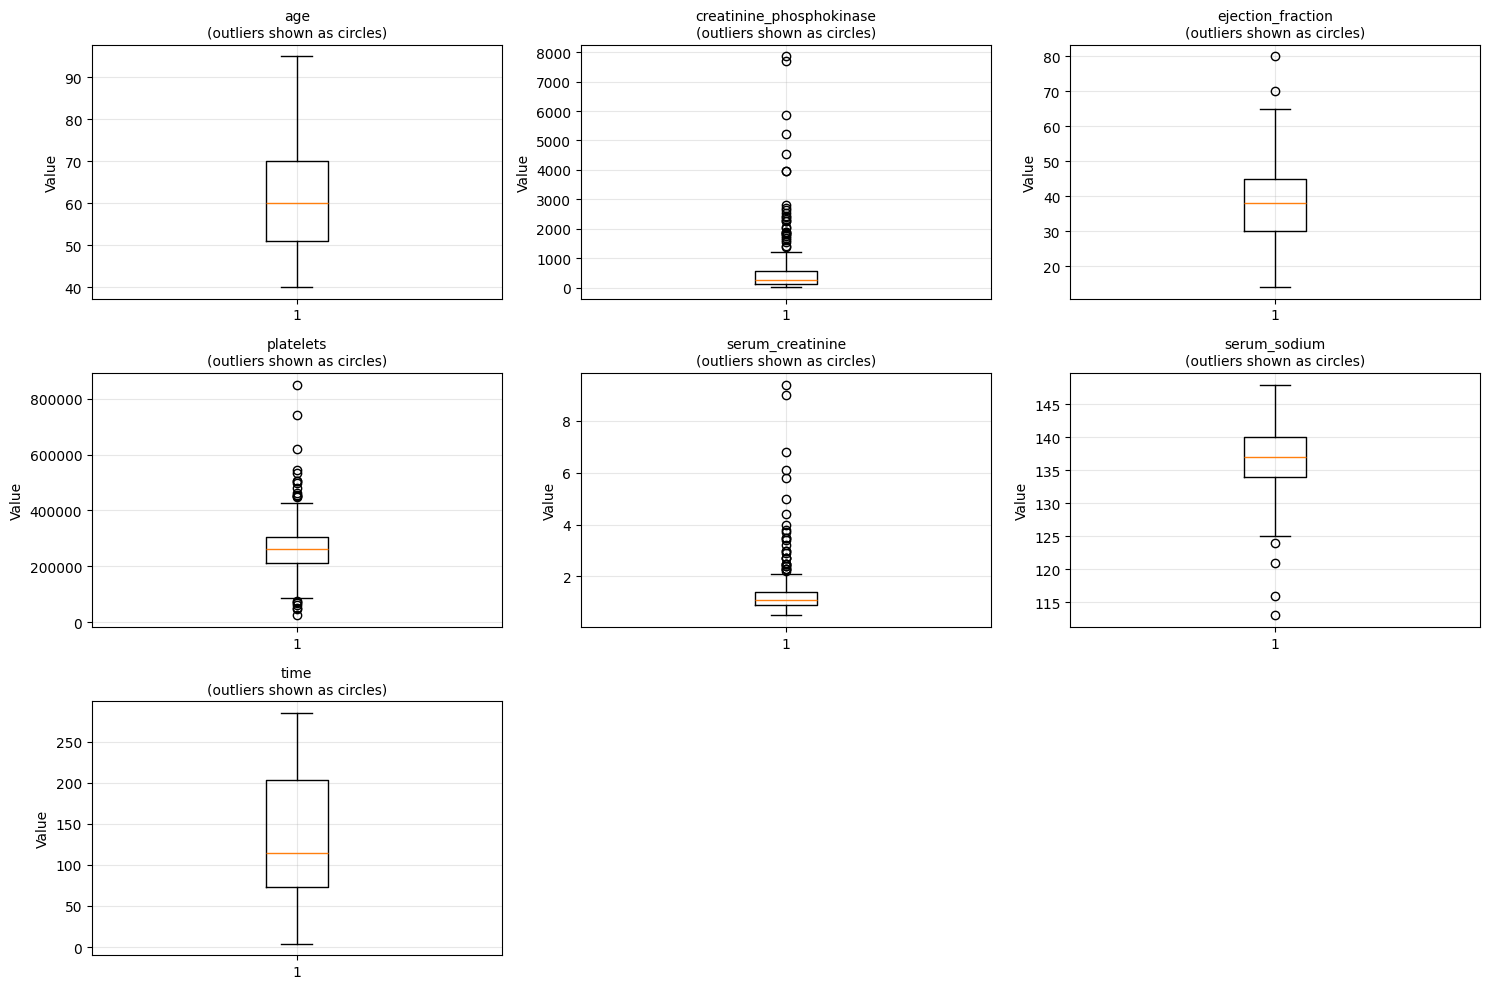

✓ Saved box plots to 'outliers_boxplot.png'


IndexError: index 6 is out of bounds for axis 0 with size 6

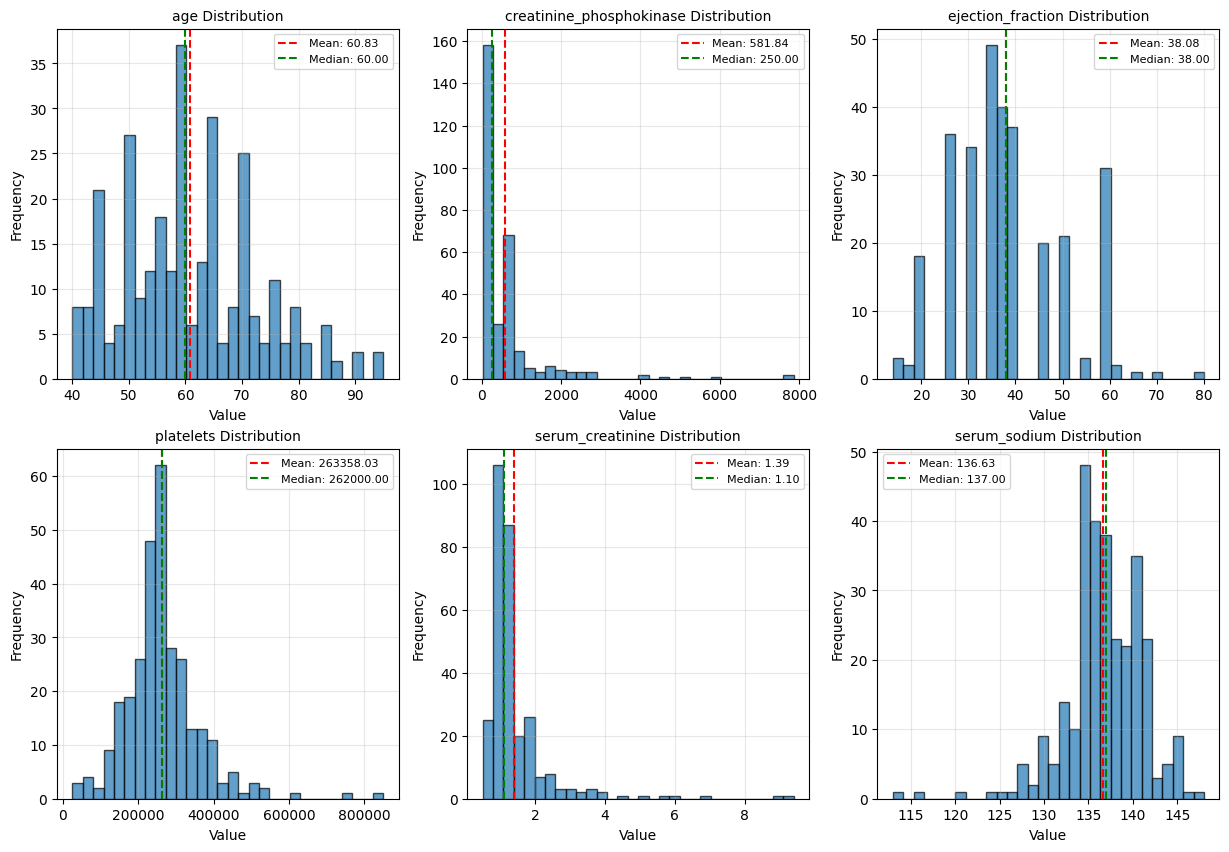

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================
# METHOD 1: Statistical Summary & IQR Method
# ============================================

def detect_outliers_iqr(df, columns):
    """
    Detect outliers using Interquartile Range (IQR) method
    Outliers are values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
    """
    outlier_info = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

        outlier_info[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_values': outliers.values
        }

    return outlier_info

# Apply to continuous features
print("="*60)
print("OUTLIER DETECTION - IQR METHOD")
print("="*60)

outlier_results = detect_outliers_iqr(data, CONTINUOUS_FEATURES)

for feature, info in outlier_results.items():
    print(f"\n{feature.upper()}:")
    print(f"  Outlier count: {info['count']} ({info['percentage']:.2f}%)者に {info['percentage']:.2f}%) ")
    print(f"  Valid range: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}] ")
    if info['count'] > 0 and info['count'] <= 10:
        print(f"  Outlier values: {info['outlier_values'][:10]}")

# ============================================
# METHOD 2: Z-Score Method
# ============================================

def detect_outliers_zscore(df, columns, threshold=3):
    """
    Detect outliers using Z-score method
    Outliers are values with |z-score| > threshold (typically 3)
    """
    outlier_info = {}

    for col in columns:
        z_scores = np.abs(stats.zscore(df[col]))
        outliers = df[z_scores > threshold][col]

        outlier_info[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'outlier_values': outliers.values
        }

    return outlier_info

print("\n" + "="*60)
print("OUTLIER DETECTION - Z-SCORE METHOD (|z| > 3)")
print("="*60)

zscore_results = detect_outliers_zscore(data, CONTINUOUS_FEATURES, threshold=3)

for feature, info in zscore_results.items():
    print(f"\n{feature.upper()}:")
    print(f"  Outlier count: {info['count']} ({info['percentage']:.2f}%) ")
    if info['count'] > 0 and info['count'] <= 10:
        print(f"  Outlier values: {info['outlier_values'][:10]}")

# ============================================
# METHOD 3: Visualization - Box Plots
# ============================================

print("\n" + "="*60)
print("GENERATING BOX PLOTS FOR VISUAL INSPECTION")
print("="*60)

# Create box plots for all continuous features
fig, axes = plt.subplots(3, 3, figsize=(15, 10)) # Changed from (2, 3) to (3, 3)
axes = axes.ravel()

for idx, feature in enumerate(CONTINUOUS_FEATURES):
    if idx < len(axes): # Added check to prevent IndexError
        axes[idx].boxplot(data[feature].dropna(), vert=True)
        axes[idx].set_title(f'{feature}\n(outliers shown as circles)', fontsize=10)
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(CONTINUOUS_FEATURES), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved box plots to 'outliers_boxplot.png'")

# ============================================
# METHOD 4: Distribution Plots (Histograms)
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(CONTINUOUS_FEATURES):
    axes[idx].hist(data[feature].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{feature} Distribution', fontsize=10)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(data[feature].mean(), color='red', linestyle='--', label=f'Mean: {data[feature].mean():.2f}')
    axes[idx].axvline(data[feature].median(), color='green', linestyle='--', label=f'Median: {data[feature].median():.2f}')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outliers_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved histograms to 'outliers_histogram.png'")

# ============================================
# METHOD 5: Summary Table
# ============================================

print("\n" + "="*60)
print("OUTLIER SUMMARY TABLE")
print("="*60)

summary_data = []
for feature in CONTINUOUS_FEATURES:
    iqr_count = outlier_results[feature]['count']
    zscore_count = zscore_results[feature]['count']
    min_val = data[feature].min()
    max_val = data[feature].max()
    mean_val = data[feature].mean()
    median_val = data[feature].median()

    summary_data.append({
        'Feature': feature,
        'Min': f"{min_val:.2f}",
        'Max': f"{max_val:.2f}",
        'Mean': f"{mean_val:.2f}",
        'Median': f"{median_val:.2f}",
        'IQR_Outliers': iqr_count,
        'Z_Outliers': zscore_count
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ============================================
# CLINICAL INTERPRETATION
# ============================================

print("\n" + "="*60)
print("CLINICAL INTERPRETATION OF POTENTIAL OUTLIERS")
print("="*60)

interpretations = {
    'age': "Ages 40-95 are all clinically plausible. No removal needed.",
    'creatinine_phosphokinase': "Very high CPK (>5000) can indicate severe muscle damage. May be real extreme cases.",
    'ejection_fraction': "EF 14-80% all medically possible. Low EF (<20%) indicates severe heart failure.",
    'platelets': "Extreme values (>600k or <50k) are medically significant and should be kept.",
    'serum_creatinine': "Very high values (>5) indicate severe kidney dysfunction. Clinically important.",
    'serum_sodium': "Values 113-148 are all physiologically possible, though extremes are dangerous."
}

for feature, interpretation in interpretations.items():
    print(f"\n{feature.upper()}:")
    print(f"  {interpretation}")

# ============================================
# RECOMMENDATION FUNCTION
# ============================================

def outlier_recommendations(outlier_results, data):
    """Provide recommendations on outlier handling"""

    print("\n" + "="*60)
    print("RECOMMENDATIONS FOR OUTLIER HANDLING")
    print("="*60)

    for feature, info in outlier_results.items():
        pct = info['percentage']

        print(f"\n{feature}:")

        if pct == 0:
            print("  ✓ No outliers detected. No action needed.")
        elif pct < 1:
            print(f"  ⚠ {info['count']} outliers ({pct:.2f}%) ")
            print("  → RECOMMEND: Keep these values - likely represent severe but real cases")
        elif pct < 5:
            print(f"  ⚠⚠ {info['count']} outliers ({pct:.2f}%) ")
            print("  → RECOMMEND: Investigate individually. Consider capping at 99th percentile.")
        else:
            print(f"  ⚠⚠⚠ {info['count']} outliers ({pct:.2f}%) ")
            print("  → RECOMMEND: Review data collection. May indicate data quality issues.")

        # Show skewness
        skewness = data[feature].skew()
        print(f"  Skewness: {skewness:.2f} ", end="")
        if abs(skewness) > 1:
            print("(Highly skewed - consider log transform)")
        elif abs(skewness) > 0.5:
            print("(Moderately skewed)")
        else:
            print("(Approximately symmetric)")

outlier_recommendations(outlier_results, data)

# ============================================
# OPTIONAL: Outlier Handling Functions
# ============================================
'''
print("\n" + "="*60)
print("OUTLIER HANDLING OPTIONS (OPTIONAL)")
print("="*60)

def cap_outliers(df, column, lower_percentile=1, upper_percentile=99):
    """Cap outliers at specified percentiles"""
    lower = df[column].quantile(lower_percentile / 100)
    upper = df[column].quantile(upper_percentile / 100)

    df_capped = df.copy()
    df_capped[column] = df_capped[column].clip(lower=lower, upper=upper)

    return df_capped'''

'''def remove_outliers(df, column, method='iqr'):
    """Remove outliers (NOT RECOMMENDED for this dataset)"""
    if method == 'iqr':
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df[(df[column] >= lower) & (df[column] <= upper)]
    elif method == 'zscore':
        z_scores = np.abs(stats.zscore(df[column]))
        df_clean = df[z_scores < 3]

    return df_clean'''
'''
print("\n" + "="*60)
print("Available functions for outlier handling:

1. cap_outliers(df, column, lower_percentile=1, upper_percentile=99)
   - Caps extreme values at specified percentiles
   - RECOMMENDED for this dataset if needed

2. remove_outliers(df, column, method='iqr')
   - Removes outliers entirely
   - NOT RECOMMENDED for clinical data (lose important extreme cases)

Example usage:
  data_capped = cap_outliers(data, 'creatinine_phosphokinase', 1, 99)
")'''

# ============================================
# FINAL RECOMMENDATION
# ============================================
'''
print("\n" + "="*60)
print("FINAL RECOMMENDATION FOR YOUR PROJECT")
print("="*60)
print("""
For this Heart Failure dataset:

1. DO NOT REMOVE OUTLIERS
   - These are likely real extreme clinical cases
   - They represent severe conditions that are medically important
   - Removing them would bias your model away from high-risk patients

2. CONSIDER LOG TRANSFORMATION
   - For highly skewed features (creatinine_phosphokinase, platelets)
   - Helps algorithms that assume normality

3. USE ROBUST SCALING
   - Instead of StandardScaler, use RobustScaler
   - Less sensitive to outliers

4. TREE-BASED MODELS
   - Random Forest, XGBoost naturally handle outliers well
   - Don't require outlier removal

5. DOCUMENT YOUR DECISION
   - In your report, explain why you kept outliers
   - Show you analyzed them but chose to preserve clinical reality
""")'''

---
## 5. Create Train/Test Split

**CRITICAL**: This split must be identical for ALL team members.

### Investigation Prompt:
> Why do we use `stratify=y`? What could go wrong if we don't stratify with imbalanced classes?

In [ ]:
# Separate features and target
X = data.drop(columns=[TARGET_COLUMN])
y = data[TARGET_COLUMN]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (299, 12)
Target shape: (299,)


In [ ]:
Xt = data.drop(columns=[TARGET_COLUMN, 'time'])

In [ ]:
# TODO: Create train/test split
# Hint: Use train_test_split with stratify=y for balanced classes in both sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 239
Test set size: 60

Training target distribution:
DEATH_EVENT
0    0.677824
1    0.322176
Name: proportion, dtype: float64

Test target distribution:
DEATH_EVENT
0    0.683333
1    0.316667
Name: proportion, dtype: float64


In [ ]:
# without time feature
Xt_train, Xt_test, y_train, y_test = train_test_split(Xt, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 239
Test set size: 60

Training target distribution:
DEATH_EVENT
0    0.677824
1    0.322176
Name: proportion, dtype: float64

Test target distribution:
DEATH_EVENT
0    0.683333
1    0.316667
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Create scaled versions
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[CONTINUOUS_FEATURES] = scaler.fit_transform(X_train[CONTINUOUS_FEATURES])
X_test_scaled[CONTINUOUS_FEATURES] = scaler.transform(X_test[CONTINUOUS_FEATURES])

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Create scaled versions
scaler = StandardScaler()
Xt_train_scaled = Xt_train.copy()
Xt_test_scaled = Xt_test.copy()

Xt_train_scaled[CONTINUOUS_T_FEATURES] = scaler.fit_transform(Xt_train[CONTINUOUS_T_FEATURES])
Xt_test_scaled[CONTINUOUS_T_FEATURES] = scaler.transform(Xt_test[CONTINUOUS_T_FEATURES])

---
## 6. Save Split Data

Save train and test sets so all team members use identical data.

In [ ]:
os.makedirs('/content/data', exist_ok=True)

# Combine features and target for saving
train_data = X_train_scaled.copy()
train_data[TARGET_COLUMN] = y_train

test_data = X_test_scaled.copy()
test_data[TARGET_COLUMN] = y_test

# Save to CSV
train_data.to_csv('/content/data/train.csv', index=False)
test_data.to_csv('/content/data/test.csv', index=False)

print("Saved: ../data/train.csv")
print("Saved: ../data/test.csv")
#print("\nAll team members should now use these files!")

Saved: ../data/train.csv
Saved: ../data/test.csv


In [ ]:
#os.makedirs('/content/data', exist_ok=True)

# Combine features and target for saving
trainT_data = Xt_train_scaled.copy()
trainT_data[TARGET_COLUMN] = y_train

testT_data = Xt_test_scaled.copy()
testT_data[TARGET_COLUMN] = y_test

# Save to CSV
trainT_data.to_csv('/content/data/trainT.csv', index=False)
testT_data.to_csv('/content/data/testT.csv', index=False)

print("Saved: ../data/trainT.csv")
print("Saved: ../data/testT.csv")
#print("\nAll team members should now use these files!")

Saved: ../data/trainT.csv
Saved: ../data/testT.csv


---
## 7. Select Example Indices for Task 4

**Team Decision Required**: Choose specific indices for positive and negative examples that ALL members will use for the final comparison in Task 4.

### Investigation Prompt:
> Why is it important that all team members use the SAME examples for comparison? What would happen if each member picked different examples?

In [ ]:
# Find indices of positive (death=1) and negative (death=0) examples in test set
positive_indices = test_data[test_data[TARGET_COLUMN] == 1].index.tolist()
negative_indices = test_data[test_data[TARGET_COLUMN] == 0].index.tolist()

print(f"Positive examples (death=1) in test set: {len(positive_indices)}")
print(f"Negative examples (death=0) in test set: {len(negative_indices)}")

print(f"\nFirst 5 positive indices: {positive_indices}")
print(f"First 5 negative indices: {negative_indices}")

Positive examples (death=1) in test set: 19
Negative examples (death=0) in test set: 41

First 5 positive indices: [7, 10, 11, 12, 14, 15, 16, 17, 27, 28, 33, 35, 36, 38, 40, 47, 49, 52, 57]
First 5 negative indices: [0, 1, 2, 3, 4, 5, 6, 8, 9, 13, 18, 19, 20, 21, 22, 23, 24, 25, 26, 29, 30, 31, 32, 34, 37, 39, 41, 42, 43, 44, 45, 46, 48, 50, 51, 53, 54, 55, 56, 58, 59]


In [ ]:
# Find indices of positive (death=1) and negative (death=0) examples in test set
positive_indices = testT_data[testT_data[TARGET_COLUMN] == 1].index.tolist()
negative_indices = testT_data[testT_data[TARGET_COLUMN] == 0].index.tolist()

print(f"Positive examples (death=1) in test set: {len(positive_indices)}")
print(f"Negative examples (death=0) in test set: {len(negative_indices)}")

print(f"\nFirst 5 positive indices: {positive_indices}")
print(f"First 5 negative indices: {negative_indices}")

Positive examples (death=1) in test set: 19
Negative examples (death=0) in test set: 41

First 5 positive indices: [110, 213, 68, 140, 113, 119, 148, 16, 10, 183, 65, 17, 49, 42, 230, 63, 35, 246, 26]
First 5 negative indices: [274, 149, 120, 226, 125, 298, 130, 275, 190, 264, 282, 205, 85, 267, 135, 287, 254, 129, 244, 86, 179, 196, 295, 77, 103, 20, 251, 291, 166, 189, 284, 222, 168, 117, 193, 122, 242, 210, 172, 221, 145]


In [ ]:
# TODO: As a team, agree on which indices to use
# These should be used by ALL members for Task 4 comparison

# Example (team should verify/change these):
POSITIVE_EXAMPLE_IDX = 35  # TODO: Fill in after team discussion
NEGATIVE_EXAMPLE_IDX = 20  # TODO: Fill in after team discussion

print("\n" + "="*50)
print("TEAM TASK: Agree on example indices and update above!")
print("="*50)


TEAM TASK: Agree on example indices and update above!


---
## 8. Summary

### What was accomplished:
- Loaded and validated the Heart Failure dataset
- Created reproducible train/test split (80/20, stratified)
- Saved split data for team consistency

### Next Steps:
1. Each team member opens their assigned notebook
2. Load data from `../data/train.csv` and `../data/test.csv`
3. Use the same `RANDOM_STATE = 42` for any additional random operations

### Key Values to Remember:
```python
RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COLUMN = 'DEATH_EVENT'
POSITIVE_EXAMPLE_IDX = ???  # Team decides
NEGATIVE_EXAMPLE_IDX = ???  # Team decides
```

# Member B: Decision Tree + Random Forest + eli5/LIME Interpretability
## CS667 Project 4: ML Interpretability

**Assigned Tasks:**
- EDA Focus: Feature distributions
- Models: Decision Tree + Random Forest with GridSearchCV
- Interpretability: eli5 for DT (Task 3_B) + LIME for RF (Task 3_C partial)

**Prerequisites:** Run `00_data_preparation.ipynb` first!

---
# Part 1: Setup and Data Loading

In [ ]:
%pip install eli5 -q

In [ ]:
%pip install lime -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import joblib

import eli5
from eli5.sklearn import PermutationImportance

import lime
import lime.lime_tabular

# Shared constants
RANDOM_STATE = 42
TARGET_COLUMN = 'DEATH_EVENT'

In [ ]:
# Load the pre-split data
train_data = pd.read_csv('/content/data/train.csv')
test_data = pd.read_csv('/content/data/test.csv')

X_train = train_data.drop(columns=[TARGET_COLUMN])
y_train = train_data[TARGET_COLUMN]
X_test = test_data.drop(columns=[TARGET_COLUMN])
y_test = test_data[TARGET_COLUMN]

feature_names = X_train.columns.tolist()

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {feature_names}")

Training samples: 239
Test samples: 60
Features: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']


In [ ]:
# Load the pre-split data
trainT_data = pd.read_csv('/content/data/trainT.csv')
testT_data = pd.read_csv('/content/data/testT.csv')

Xt_train = trainT_data.drop(columns=[TARGET_COLUMN])
yt_train = trainT_data[TARGET_COLUMN]
Xt_test = testT_data.drop(columns=[TARGET_COLUMN])
yt_test = testT_data[TARGET_COLUMN]

feature_names = Xt_train.columns.tolist()

print(f"Training samples: {len(Xt_train)}")
print(f"Test samples: {len(Xt_test)}")
print(f"Features: {feature_names}")

Training samples: 239
Test samples: 60
Features: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']


---
# Part 2: Exploratory Data Analysis

**Your EDA Focus**: Feature distributions (univariate analysis).

### Investigation Prompts:
> - How are continuous features distributed? Are there outliers?
> - What is the distribution of binary features across the two classes?
> - Do any features show clear separation between death/survival groups?

In [ ]:
# Define feature types
BINARY_FEATURES = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
CONTINUOUS_FEATURES = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                       'platelets', 'serum_creatinine', 'serum_sodium', 'time']

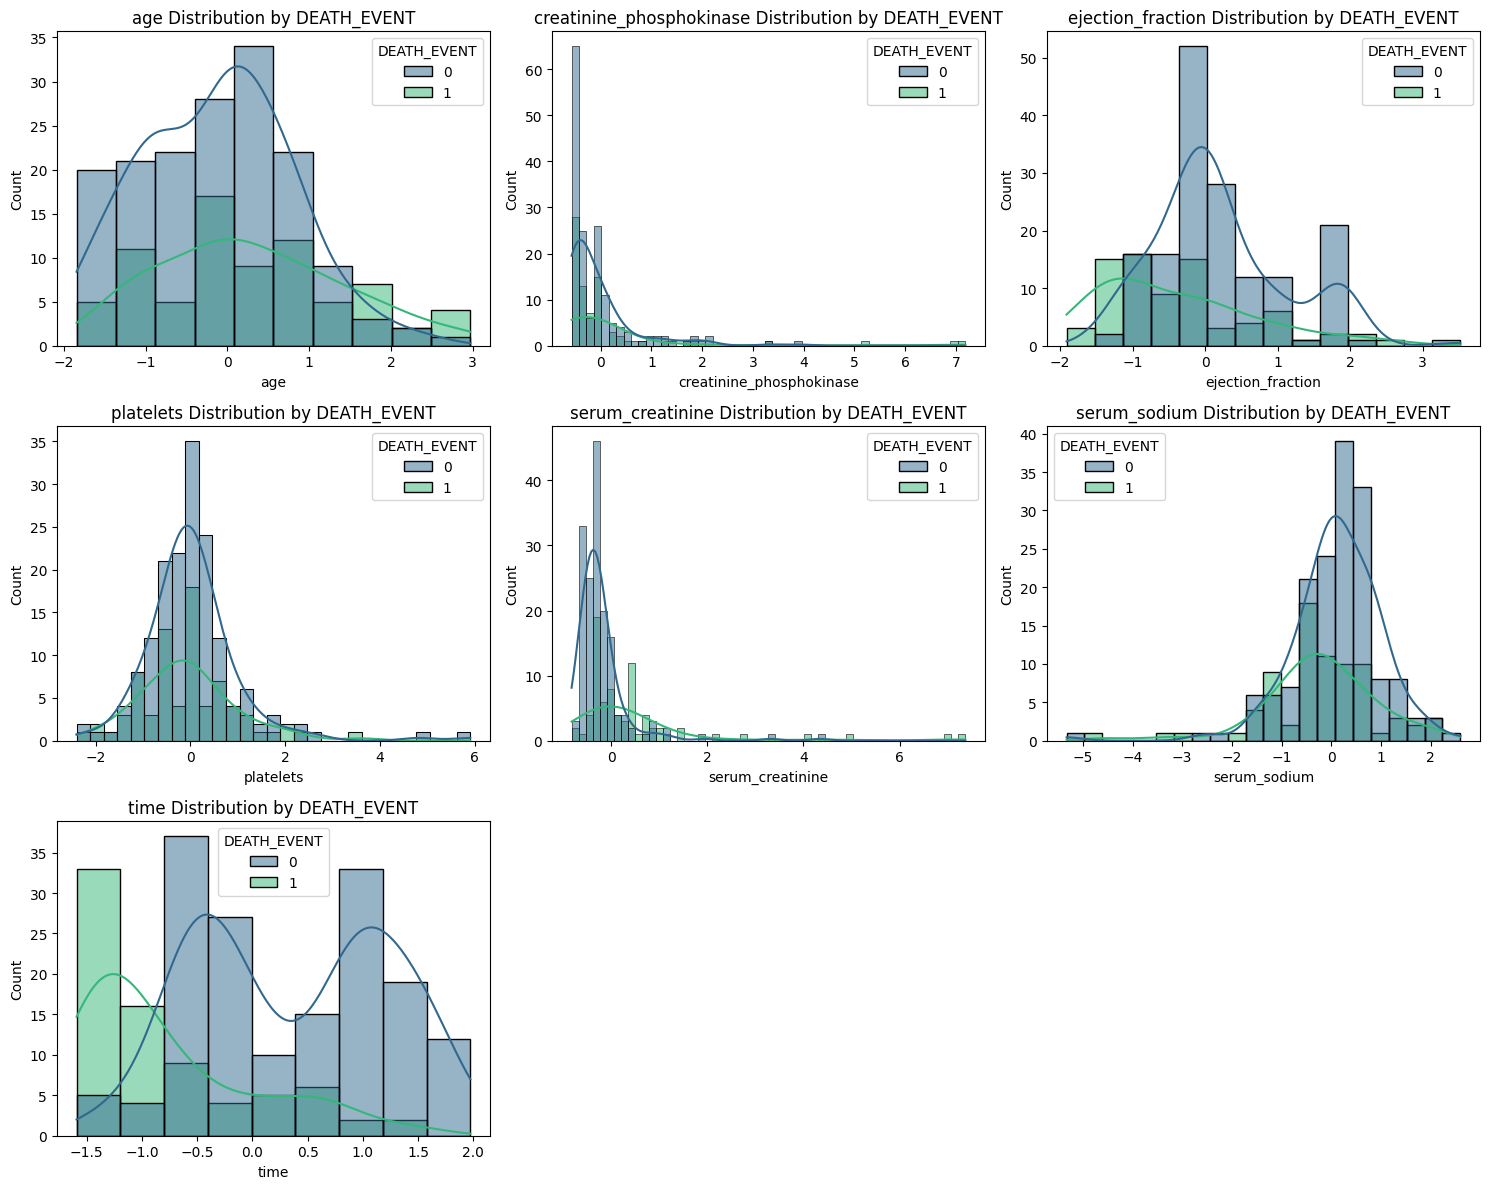

In [ ]:
# Create the directory if it doesn't exist
os.makedirs('../visualizations', exist_ok=True)

# TODO: Create histograms for continuous features, colored by target
# Hint: Use train_data for EDA, with hue=TARGET_COLUMN

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(CONTINUOUS_FEATURES):
    if i < len(axes):
        sns.histplot(data=train_data, x=feature, hue=TARGET_COLUMN, kde=True, ax=axes[i], palette='viridis')
        axes[i].set_title(f'{feature} Distribution by {TARGET_COLUMN}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Count')

# Hide any unused subplots
for i in range(len(CONTINUOUS_FEATURES), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('../visualizations/continuous_distributions.png', dpi=150)
plt.show()

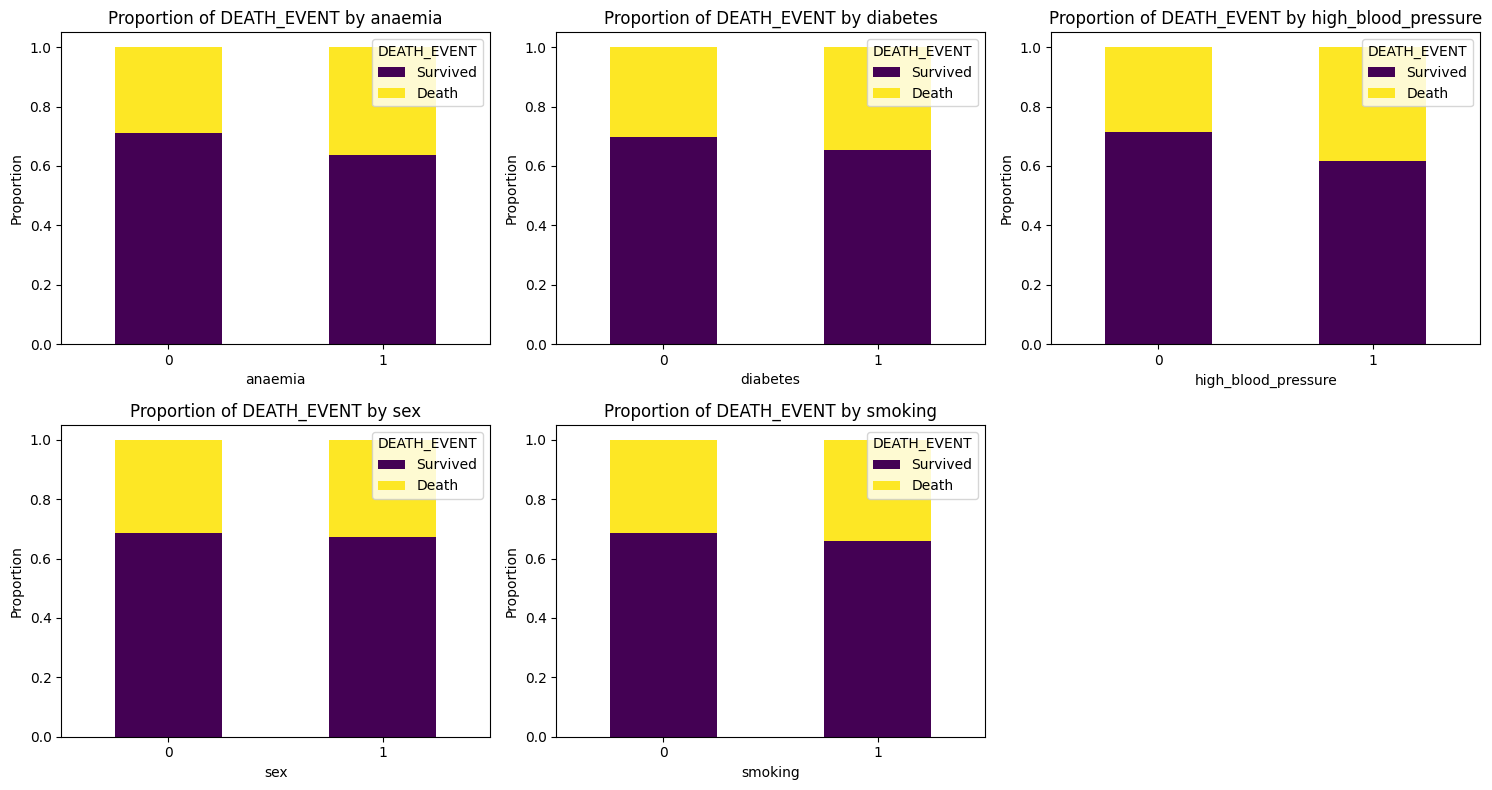

In [ ]:
# TODO: Create bar plots for binary features, showing proportions by target
# Hint: Crosstab or groupby can help calculate proportions

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(BINARY_FEATURES):
    if i < len(axes):
        # Calculate proportions of target for each binary feature category
        proportions = pd.crosstab(train_data[feature], train_data[TARGET_COLUMN], normalize='index')
        proportions.plot(kind='bar', stacked=True, ax=axes[i], cmap='viridis')
        axes[i].set_title(f'Proportion of {TARGET_COLUMN} by {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Proportion')
        axes[i].tick_params(axis='x', rotation=0)
        axes[i].legend(title=TARGET_COLUMN, labels=['Survived', 'Death'])

# Hide any unused subplots
for i in range(len(BINARY_FEATURES), len(axes)):
    fig.delaxes(axes[i])

os.makedirs('../visualizations', exist_ok=True)
plt.tight_layout()
plt.savefig('../visualizations/binary_distributions.png', dpi=150)
plt.show()

### EDA Findings:

*Document your key observations:*

1. Features showing clear separation between classes: ...
2. Outliers detected in: ...
3. Skewed distributions: ...
4. Implications for tree-based models: ...

he exploratory data analysis for both continuous and binary features is complete. Here are my key observations:

Continuous Features (Histograms by 'DEATH_EVENT'):

age: The distribution is somewhat right-skewed, peaking around 60 years. While both survival and death occur across age groups, there's a slightly higher proportion of death observed in older patients.

creatinine_phosphokinase: This feature is highly right-skewed, with most values at the lower end. Outliers are present, as noted in the previous cell. While death events occur across the range, no strong separation is immediately visible from this plot.

ejection_fraction: The distribution peaks between 30-40%. Patients with lower ejection fractions (indicating poorer heart function) appear to have a higher likelihood of experiencing a death event.

platelets: The distribution is relatively symmetric around 250,000

kiloplatelets/mL. Death events are distributed across the range without a strong distinguishing pattern.

serum_creatinine: Similar to creatinine_phosphokinase, this feature is highly right-skewed. Higher levels of serum creatinine (suggesting kidney dysfunction) tend to be more prevalent in the death group.

serum_sodium: The distribution is roughly symmetrical around 137 mEq/L. There's a slight indication that lower serum sodium levels might be associated with a higher proportion of death events.

time: This is the strongest feature for separation. Patients with shorter follow-up periods (lower 'time' values) show a substantially higher proportion of death events, while those with longer follow-up periods are predominantly in the survival group.

Binary Features (Stacked Bar Plots):

anaemia: Patients with anaemia (value 1) show a slightly higher proportion of death events compared to those without anaemia (value 0).

diabetes: The proportions of death and survival are very similar between diabetic (1) and non-diabetic (0) patients, suggesting it may not be a strong individual predictor.

high_blood_pressure: Individuals with high blood pressure (1) exhibit a somewhat higher proportion of death events than those without (0).

sex: There is a minimal difference in the proportion of death events between sexes (0 and 1, likely female and male respectively), indicating it might not be a highly influential predictor on its own.

smoking: Similar to diabetes, the smoking status (1 for smoker, 0 for non-smoker) does not show a significant difference in the proportion of death events.

EDA Findings Summary (addressing investigation prompts):

Features showing clear separation between classes:
'time' is the most discriminative feature. 'ejection_fraction' (lower values) and 'serum_creatinine' (higher values) also show a noticeable difference in distributions between the two classes. 'anaemia' and 'high_blood_pressure' show slight differences.

Outliers detected in: As confirmed by the previous cell's output and visually in the box plots, significant outliers are present in creatinine_phosphokinase, ejection_fraction, platelets, serum_creatinine, and serum_sodium. age and time did not show outliers by the IQR method.

Skewed distributions: creatinine_phosphokinase and serum_creatinine are highly right-skewed. age and platelets are moderately skewed.

Implications for tree-based models: Tree-based models like Decision Trees and Random Forests are generally robust to outliers and don't strictly require feature scaling or complex outlier handling methods like capping or removal. They can naturally handle skewed distributions well. However, understanding these characteristics is important for interpretability and for potentially using other types of models that might be sensitive to such data properties.

---
# Part 3: Decision Tree Modeling

### Investigation Prompts:
> - What hyperparameters control Decision Tree complexity?
> - What is the risk of overfitting with deep trees?
> - Why don't trees require feature scaling?

In [ ]:
# TODO: Define the hyperparameter grid for Decision Tree
# Consider: max_depth, min_samples_split, min_samples_leaf, criterion

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print(f"DT Parameter grid: {dt_param_grid}")

DT Parameter grid: {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}


In [ ]:
# TODO: Perform GridSearchCV for Decision Tree

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_grid_search = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit
dt_grid_search.fit(X_train, y_train)

print(f"Best DT parameters: {dt_grid_search.best_params_}")
print(f"Best DT CV AUC-ROC: {dt_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best DT parameters: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best DT CV AUC-ROC: 0.8293


In [ ]:
# TODO: Perform GridSearchCV for Decision Tree

dt_t = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_t_grid_search = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit
dt_t_grid_search.fit(Xt_train, yt_train)

print(f"Best DT parameters: {dt_grid_search.best_params_}")
print(f"Best DT CV AUC-ROC: {dt_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best DT parameters: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best DT CV AUC-ROC: 0.7432


In [ ]:
# Evaluate Decision Tree on test set
best_dt = dt_grid_search.best_estimator_

y_pred_dt = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_auc_roc = roc_auc_score(y_test, y_proba_dt)

print(f"\n=== Decision Tree Results ===")
print(f"Test Accuracy: {dt_accuracy:.4f}")
print(f"Test AUC-ROC: {dt_auc_roc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


=== Decision Tree Results ===
Test Accuracy: 0.8000
Test AUC-ROC: 0.8293

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.98      0.87        41
           1       0.89      0.42      0.57        19

    accuracy                           0.80        60
   macro avg       0.84      0.70      0.72        60
weighted avg       0.82      0.80      0.78        60



In [ ]:
# Evaluate Decision Tree on test set
best_dt_t = dt_t_grid_search.best_estimator_

yt_pred_dt = best_dt_t.predict(Xt_test)
yt_proba_dt = best_dt_t.predict_proba(Xt_test)[:, 1]

dt_t_accuracy = accuracy_score(yt_test, yt_pred_dt)
dt_t_auc_roc = roc_auc_score(yt_test, yt_proba_dt)

print(f"\n=== Decision Tree Results ===")
print(f"Test Accuracy: {dt_t_accuracy:.4f}")
print(f"Test AUC-ROC: {dt_t_auc_roc:.4f}")
print(f"\nClassification Report:")
print(classification_report(yt_test, yt_pred_dt))


=== Decision Tree Results ===
Test Accuracy: 0.7833
Test AUC-ROC: 0.7619

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        41
           1       0.71      0.53      0.61        19

    accuracy                           0.78        60
   macro avg       0.76      0.71      0.73        60
weighted avg       0.78      0.78      0.77        60



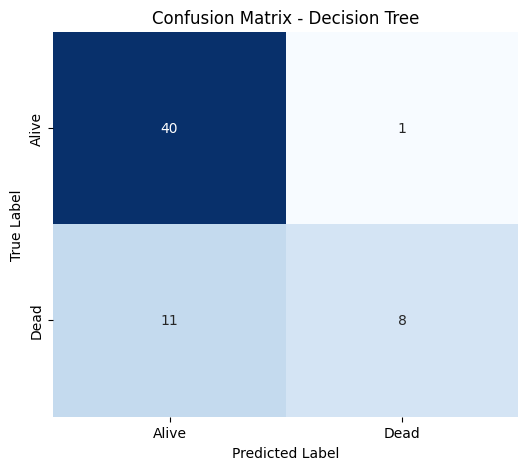

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Alive', 'Dead'],
            yticklabels=['Alive', 'Dead'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

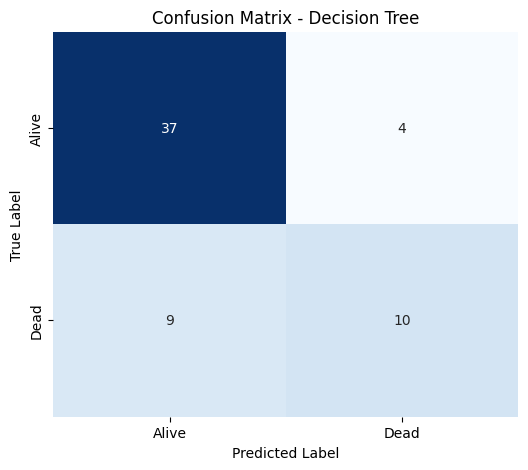

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm_dt_t = confusion_matrix(yt_test, yt_pred_dt)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt_t, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Alive', 'Dead'],
            yticklabels=['Alive', 'Dead'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
import os
os.makedirs('../models', exist_ok=True)
# Save Decision Tree model
joblib.dump(best_dt, '../models/decision_tree_best.pkl')
print("Decision Tree model saved.")

Decision Tree model saved.


In [ ]:
import os
os.makedirs('../models', exist_ok=True)
# Save Decision Tree model
joblib.dump(best_dt_t, '../models/decision_tree_t_best.pkl')
print("Decision Tree without time model saved.")

Decision Tree without time model saved.


---
# Part 5: eli5 for Decision Tree (Task 3_B)

## eli5 Investigation Prompts for Trees

> **Research these questions:**
>
> 1. How does eli5 calculate feature importance for Decision Trees?
> 2. What does `eli5.show_prediction()` show for tree-based models vs. linear models?
> 3. How can you trace the decision path through a tree for a specific prediction?
> 4. Why might eli5 feature importance differ from sklearn's `feature_importances_`?

### 5.1 Feature Importance with eli5

In [ ]:
# TODO: Use eli5.show_weights() to display feature importance
# Hint: Pass feature_names for readability

eli5.show_weights(best_dt, feature_names=feature_names)

Weight,Feature
0.7322,time
0.1324,serum_creatinine
0.0974,ejection_fraction
0.0380,serum_sodium
0,sex
0,smoking
0,platelets
0,high_blood_pressure
0,diabetes
0,creatinine_phosphokinase


In [ ]:
# TODO: Use eli5.show_weights() to display feature importance
# Hint: Pass feature_names for readability

eli5.show_weights(best_dt_t, feature_names=feature_names)

Weight,Feature
0.4931,serum_creatinine
0.3068,ejection_fraction
0.1052,age
0.0567,smoking
0.0382,serum_sodium
0,sex
0,platelets
0,high_blood_pressure
0,diabetes
0,creatinine_phosphokinase


In [ ]:
# TODO: Compare with sklearn's built-in feature_importances_
# Are they the same? Why or why not?

sklearn_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False)

print("sklearn feature_importances_:")
print(sklearn_importance)

sklearn feature_importances_:
                     feature  importance
11                      time    0.732192
7           serum_creatinine    0.132382
4          ejection_fraction    0.097413
8               serum_sodium    0.038013
3                   diabetes    0.000000
2   creatinine_phosphokinase    0.000000
1                    anaemia    0.000000
0                        age    0.000000
6                  platelets    0.000000
5        high_blood_pressure    0.000000
9                        sex    0.000000
10                   smoking    0.000000


In [ ]:
# TODO: Compare with sklearn's built-in feature_importances_
# Are they the same? Why or why not?

sklearn_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_dt_t.feature_importances_
}).sort_values('importance', ascending=False)

print("sklearn feature_importances_:")
print(sklearn_importance)

sklearn feature_importances_:
                     feature  importance
7           serum_creatinine    0.493103
4          ejection_fraction    0.306783
0                        age    0.105160
10                   smoking    0.056732
8               serum_sodium    0.038222
2   creatinine_phosphokinase    0.000000
1                    anaemia    0.000000
6                  platelets    0.000000
5        high_blood_pressure    0.000000
3                   diabetes    0.000000
9                        sex    0.000000


### 5.2 Explain Specific Predictions

In [ ]:
# TODO: Explain prediction for POSITIVE example using eli5
# Hint: For trees, eli5.show_prediction() traces the decision path
print("=== Decision Tree Explanation for POSITIVE Example ===")
eli5.show_prediction(best_dt, X_test.loc[positive_idx].to_frame().T, feature_names=feature_names)

=== Decision Tree Explanation for POSITIVE Example ===


In [ ]:
# TODO: Explain prediction for POSITIVE example using eli5
# Hint: For trees, eli5.show_prediction() traces the decision path
print("=== Decision Tree Explanation for POSITIVE Example ===")
eli5.show_prediction(best_dt_t, Xt_test.loc[POSITIVE_EXAMPLE_IDX].to_frame().T, feature_names=feature_names)

=== Decision Tree Explanation for POSITIVE Example ===


In [ ]:
# TODO: Explain prediction for NEGATIVE example

print("=== Decision Tree Explanation for NEGATIVE Example ===")
eli5.show_prediction(best_dt, X_test.loc[negative_idx].to_frame().T, feature_names=feature_names)

=== Decision Tree Explanation for NEGATIVE Example ===


In [ ]:
# TODO: Explain prediction for NEGATIVE example

print("=== Decision Tree Explanation for NEGATIVE Example ===")
eli5.show_prediction(best_dt_t, Xt_test.loc[NEGATIVE_EXAMPLE_IDX].to_frame().T, feature_names=feature_names)

=== Decision Tree Explanation for NEGATIVE Example ===


---
# Part 4: Random Forest Modeling

### Investigation Prompts:
> - How does Random Forest differ from a single Decision Tree?
> - What is the effect of n_estimators on performance vs. computation?
> - Why might Random Forest be more robust than a single tree?

In [ ]:
# TODO: Define the hyperparameter grid for Random Forest
# Consider: n_estimators, max_depth, min_samples_split, max_features

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

print(f"RF Parameter grid: {rf_param_grid}")

RF Parameter grid: {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 5, 10], 'max_features': ['sqrt', 'log2']}


In [ ]:
# TODO: Perform GridSearchCV for Random Forest

rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf_grid_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit
rf_grid_search.fit(X_train, y_train)

print(f"Best RF parameters: {rf_grid_search.best_params_}")
print(f"Best RF CV AUC-ROC: {rf_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}
Best RF CV AUC-ROC: 0.9273


In [ ]:
rf_t = RandomForestClassifier(random_state=RANDOM_STATE)

rf_t_grid_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit
rf_t_grid_search.fit(Xt_train, yt_train)

print(f"Best RF parameters: {rf_t_grid_search.best_params_}")
print(f"Best RF CV AUC-ROC: {rf_t_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV AUC-ROC: 0.7948


In [ ]:
# Evaluate Random Forest on test set
best_rf = rf_grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc_roc = roc_auc_score(y_test, y_proba_rf)

print(f"\n=== Random Forest Results ===")
print(f"Test Accuracy: {rf_accuracy:.4f}")
print(f"Test AUC-ROC: {rf_auc_roc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


=== Random Forest Results ===
Test Accuracy: 0.8333
Test AUC-ROC: 0.8947

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89        41
           1       0.85      0.58      0.69        19

    accuracy                           0.83        60
   macro avg       0.84      0.77      0.79        60
weighted avg       0.83      0.83      0.82        60



In [ ]:
# Evaluate Random Forest on test set
best_rf_t = rf_t_grid_search.best_estimator_

yt_pred_rf = best_rf_t.predict(Xt_test)
yt_proba_rf = best_rf_t.predict_proba(Xt_test)[:, 1]

rf_t_accuracy = accuracy_score(yt_test, yt_pred_rf)
rf_t_auc_roc = roc_auc_score(yt_test, yt_proba_rf)

print(f"\n=== Random Forest Results ===")
print(f"Test Accuracy: {rf_t_accuracy:.4f}")
print(f"Test AUC-ROC: {rf_t_auc_roc:.4f}")
print(f"\nClassification Report:")
print(classification_report(yt_test, yt_pred_rf))


=== Random Forest Results ===
Test Accuracy: 0.7333
Test AUC-ROC: 0.7946

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82        41
           1       0.62      0.42      0.50        19

    accuracy                           0.73        60
   macro avg       0.69      0.65      0.66        60
weighted avg       0.72      0.73      0.72        60



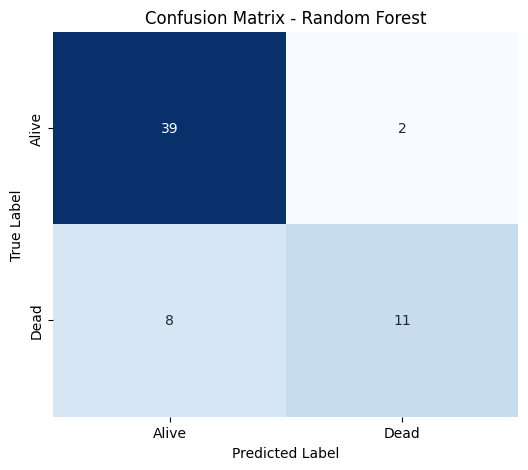

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Alive', 'Dead'],
            yticklabels=['Alive', 'Dead'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

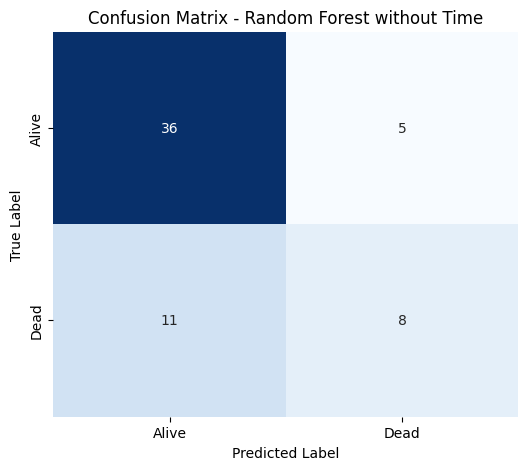

In [ ]:
cm_rf_t = confusion_matrix(yt_test, yt_pred_rf)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_t, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Alive', 'Dead'],
            yticklabels=['Alive', 'Dead'])
plt.title('Confusion Matrix - Random Forest without Time')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
import os
os.makedirs('../models', exist_ok=True) # Ensure the directory exists
# Save Random Forest model
joblib.dump(best_rf, '../models/random_forest_best.pkl')
print("Random Forest model saved.")

Random Forest model saved.


---
# Part 6: LIME for Random Forest (Task 3_C partial)

## LIME Investigation Prompts

> **Research these questions:**
>
> 1. What does LIME stand for, and what is "local" interpretability?
> 2. What parameters does `LimeTabularExplainer` require and why?
> 3. What do the coefficients from `explain_instance()` represent?
> 4. What does a low R² value tell you about the LIME explanation?
> 5. How do you access `local_exp`, `intercept`, and `score` from an explanation?

### 6.1 Create LIME Explainer

In [ ]:
# TODO: Use eli5.show_weights() to display feature importance
# Hint: Pass feature_names for readability

eli5.show_weights(best_rf, feature_names=feature_names)

Weight,Feature
0.3911 ± 0.2706,time
0.1617 ± 0.1673,serum_creatinine
0.1261 ± 0.1612,ejection_fraction
0.0785 ± 0.1033,age
0.0740 ± 0.1112,creatinine_phosphokinase
0.0638 ± 0.0794,platelets
0.0547 ± 0.0752,serum_sodium
0.0121 ± 0.0417,smoking
0.0104 ± 0.0318,anaemia
0.0103 ± 0.0301,diabetes


In [ ]:

eli5.show_weights(best_rf_t, feature_names=feature_names)

Weight,Feature
0.2887 ± 0.2571,serum_creatinine
0.2328 ± 0.2521,ejection_fraction
0.1151 ± 0.1649,age
0.1036 ± 0.1501,creatinine_phosphokinase
0.0956 ± 0.1457,serum_sodium
0.0933 ± 0.1364,platelets
0.0156 ± 0.0485,high_blood_pressure
0.0153 ± 0.0535,smoking
0.0150 ± 0.0464,anaemia
0.0141 ± 0.0468,diabetes


In [ ]:
# TODO: Create a LimeTabularExplainer
# Hint: You need training_data, feature_names, class_names, mode

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Survived', 'Death'],
    mode='classification'
)

print("LIME explainer created.")

LIME explainer created.


In [ ]:
explainer_t = lime.lime_tabular.LimeTabularExplainer(
    training_data=Xt_train.values,
    feature_names=feature_names,
    class_names=['Survived', 'Death'],
    mode='classification'
)

print("LIME explainer without time created.")

LIME explainer without time created.


### 6.2 Explain Predictions with LIME

In [ ]:
# TODO: Explain a POSITIVE example prediction
# Use explain_instance() with the RF's predict_proba

# Directly use POSITIVE_EXAMPLE_IDX as it's a label in X_test's RangeIndex
pos_instance = X_test.loc[POSITIVE_EXAMPLE_IDX].values

exp_positive = explainer.explain_instance(
    data_row=pos_instance,
    predict_fn=best_rf.predict_proba,
    num_features=len(feature_names)
)

print("=== LIME Explanation for POSITIVE Example ===")
exp_positive.show_in_notebook()

=== LIME Explanation for POSITIVE Example ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# TODO: Explain a POSITIVE example prediction
# Use explain_instance() with the RF's predict_proba

# Directly use POSITIVE_EXAMPLE_IDX as it's a label in X_test's RangeIndex
pos_instance = Xt_test.loc[POSITIVE_EXAMPLE_IDX].values

exp_positive_t = explainer_t.explain_instance(
    data_row=pos_instance,
    predict_fn=best_rf_t.predict_proba,
    num_features=len(feature_names)
)

print("=== LIME Explanation for POSITIVE Example ===")
exp_positive_t.show_in_notebook()

=== LIME Explanation for POSITIVE Example ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# TODO: Access the LIME linear model details
# The project requires: coefficients, intercept, and R²

# YOUR CODE HERE
# Hint: exp_positive.local_exp gives feature contributions
# Hint: exp_positive.intercept gives the intercept
# Hint: exp_positive.score gives the R² of the local linear model

print("\nLIME Linear Model Details (Positive Example):")
print(f"Intercept: {exp_positive.intercept[1]:.4f}") # Access intercept for 'Death' class
print(f"R² Score: {exp_positive.score:.4f}")
print("Coefficients:")
for feature, value in exp_positive.as_list(label=1): # Access coefficients for 'Death' class
    print(f"  {feature}: {value:.4f}")


LIME Linear Model Details (Positive Example):
Intercept: 0.2631
R² Score: 0.7382
Coefficients:
  time <= -0.75: 0.4576
  ejection_fraction <= -0.66: 0.1305
  serum_creatinine <= -0.45: -0.0978
  serum_sodium <= -0.57: 0.0521
  platelets <= -0.52: 0.0289
  age <= -0.84: -0.0271
  smoking <= 0.00: -0.0234
  anaemia <= 0.00: -0.0222
  high_blood_pressure <= 0.00: -0.0164
  0.00 < sex <= 1.00: -0.0146
  -0.35 < creatinine_phosphokinase <= -0.02: 0.0109
  diabetes <= 0.00: -0.0083


In [ ]:
# TODO: Access the LIME linear model details
# The project requires: coefficients, intercept, and R²

# YOUR CODE HERE
# Hint: exp_positive.local_exp gives feature contributions
# Hint: exp_positive.intercept gives the intercept
# Hint: exp_positive.score gives the R² of the local linear model

print("\nLIME Linear Model Details (Positive Example):")
print(f"Intercept: {exp_positive.intercept[1]:.4f}") # Access intercept for 'Death' class
print(f"R² Score: {exp_positive.score:.4f}")
print("Coefficients:")
for feature, value in exp_positive.as_list(label=1): # Access coefficients for 'Death' class
    print(f"  {feature}: {value:.4f}")

In [ ]:
# TODO: Access the LIME linear model details
# The project requires: coefficients, intercept, and R²

# YOUR CODE HERE
# Hint: exp_positive.local_exp gives feature contributions
# Hint: exp_positive.intercept gives the intercept
# Hint: exp_positive.score gives the R² of the local linear model

print("\nLIME Linear Model Details (Positive Example):")
print(f"Intercept: {exp_positive_t.intercept[1]:.4f}") # Access intercept for 'Death' class
print(f"R² Score: {exp_positive_t.score:.4f}")
print("Coefficients:")
for feature, value in exp_positive_t.as_list(label=1): # Access coefficients for 'Death' class
    print(f"  {feature}: {value:.4f}")


LIME Linear Model Details (Positive Example):
Intercept: 0.3571
R² Score: 0.3890
Coefficients:
  ejection_fraction <= -0.66: 0.1750
  serum_creatinine <= -0.45: -0.1455
  serum_sodium <= -0.57: 0.0806
  platelets <= -0.52: 0.0379
  age <= -0.84: -0.0357
  anaemia <= 0.00: -0.0271
  high_blood_pressure <= 0.00: -0.0237
  -0.35 < creatinine_phosphokinase <= -0.02: 0.0190
  0.00 < sex <= 1.00: -0.0154
  diabetes <= 0.00: -0.0139
  smoking <= 0.00: -0.0098


In [ ]:
# TODO: Explain a NEGATIVE example prediction

# Directly use NEGATIVE_EXAMPLE_IDX as it's a label in X_test's RangeIndex
neg_instance = X_test.loc[NEGATIVE_EXAMPLE_IDX].values

exp_negative = explainer.explain_instance(
    data_row=neg_instance,
    predict_fn=best_rf.predict_proba,
    num_features=len(feature_names)
)

print("=== LIME Explanation for NEGATIVE Example ===")
exp_negative.show_in_notebook()

=== LIME Explanation for NEGATIVE Example ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [123]:
# TODO: Explain a NEGATIVE example prediction

# Directly use NEGATIVE_EXAMPLE_IDX as it's a label in X_test's RangeIndex
neg_t_instance = Xt_test.loc[NEGATIVE_EXAMPLE_IDX].values

exp_negative_t = explainer.explain_instance(
    data_row=neg_t_instance,
    predict_fn=best_rf_t.predict_proba,
    num_features=len(feature_names)
)

print("=== LIME Explanation for NEGATIVE Example ===")
exp_negative_t.show_in_notebook()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


=== LIME Explanation for NEGATIVE Example ===


### 6.3 LIME Interpretation Summary

*Document your LIME findings:*

1. **R² Score Analysis:**
   - Positive example R²: ...
   - Negative example R²: ...
   - Is the local linear approximation trustworthy?

2. **Key Feature Contributions:**
   - Positive example top features: ...
   - Negative example top features: ...

3. **Comparison with eli5 (Decision Tree):**
   - How do LIME explanations for RF compare to eli5 for DT?
   - Any consistent features across both methods?

---
# Part 7: Individual Predictions for Task 4

In [ ]:
# TODO: Fill in the agreed indices from team discussion
POSITIVE_EXAMPLE_IDX = 35  # Update with team-agreed index
NEGATIVE_EXAMPLE_IDX = 20  # Update with team-agreed index

if POSITIVE_EXAMPLE_IDX is None:
    print("WARNING: Update example indices!")

In [ ]:
def predict_with_proba(model, X, idx, true_label, model_name):
    """Generate prediction output for Task 4 format."""
    pos = list(X.index).index(idx)
    sample = X.iloc[pos:pos+1]

    proba = model.predict_proba(sample)[0]
    pred = model.predict(sample)[0]

    print(f"{model_name} Prediction: {pred}")
    print(f"{model_name} Probabilities: [P(Survive)={proba[0]:.4f}, P(Death)={proba[1]:.4f}]")

if POSITIVE_EXAMPLE_IDX is not None:
    print("=== Positive Example (True Label: 1) ===")
    predict_with_proba(best_dt, X_test, POSITIVE_EXAMPLE_IDX, 1, "DT")
    predict_with_proba(best_rf, X_test, POSITIVE_EXAMPLE_IDX, 1, "RF")

    print("\n=== Negative Example (True Label: 0) ===")
    predict_with_proba(best_dt, X_test, NEGATIVE_EXAMPLE_IDX, 0, "DT")
    predict_with_proba(best_rf, X_test, NEGATIVE_EXAMPLE_IDX, 0, "RF")

---
# Part 8: Summary for Merge

### Decision Tree Results:

| Metric | Value |
|--------|-------|
| Best Hyperparameters | ... |
| Test Accuracy | ... |
| Test AUC-ROC | ... |

### Random Forest Results:

| Metric | Value |
|--------|-------|
| Best Hyperparameters | ... |
| Test Accuracy | ... |
| Test AUC-ROC | ... |

### Files Saved:
- `../models/decision_tree_best.pkl`
- `../models/random_forest_best.pkl`
- `../visualizations/continuous_distributions.png`
- `../visualizations/binary_distributions.png`

### Key Interpretability Findings:
1. eli5 (Decision Tree): ...
2. LIME (Random Forest): ...
3. R² assessment: ...